In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import numpy as np
import re
from collections import defaultdict, Counter
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================
DATASET_PATH = "/kaggle/input/datasets/mariamhany44/100-words-preprocessed-landmarks-cleaned-no-mask/splits/"
CACHE_PATH = "./cache"
MIN_FREQUENCY = 1  # Minimum samples per label (set to 1 for all, increase to filter rare labels)

# ============================================================================
# LOAD DATA FROM SPLIT FOLDERS
# ============================================================================
def load_split_data(dataset_path, split_name):
    """
    Load data from a specific split folder (train, val, or test)
    
    Args:
        dataset_path: Path to the main dataset directory
        split_name: Name of the split folder ('train', 'val', 'test')
    
    Returns:
        data: numpy array of sequences
        labels: numpy array of labels
        file_list: list of file paths
    """
    split_path = Path(dataset_path) / split_name
    
    if not split_path.exists():
        print(f"⚠️ Warning: {split_name} folder not found at {split_path}")
        return np.array([]), np.array([]), []
    
    print(f"📂 Loading {split_name} split from: {split_path}")
    
    files = list(split_path.glob("*.npy"))
    print(f"📁 Found {len(files)} files in {split_name}")
    
    data_list = []
    labels_list = []
    file_list = []
    
    for file_path in tqdm(files, desc=f"Loading {split_name}"):
        try:
            # Load data
            data = np.load(file_path)
            data_list.append(data)
            
            # Extract label from filename
            name = file_path.stem
            # Remove trailing numbers (video ID) to get the gloss
            label = re.sub(r'\s+\d+$', '', name)
            labels_list.append(label)
            file_list.append(file_path)
            
        except Exception as e:
            print(f"❌ Error loading {file_path.name}: {e}")
    
    return np.array(data_list, dtype=object), np.array(labels_list), file_list

def load_all_splits(dataset_path):
    """
    Load all splits (train, val, test) from the dataset
    
    Returns:
        Dictionary containing data, labels, and file lists for each split
    """
    print("="*60)
    print("📊 LOADING PRE-SPLIT DATASET")
    print("="*60)
    
    splits = {}
    
    for split_name in ['train', 'val', 'test']:
        data, labels, file_list = load_split_data(dataset_path, split_name)
        
        splits[split_name] = {
            'data': data,
            'labels': labels,
            'file_list': file_list,
            'num_samples': len(data),
            'unique_labels': len(np.unique(labels)) if len(data) > 0 else 0
        }
        
        print(f"  {split_name.capitalize()}: {len(data)} samples, {splits[split_name]['unique_labels']} unique glosses")
    
    return splits

# ============================================================================
# ANALYZE SPLIT STATISTICS
# ============================================================================
def analyze_split_distribution(splits):
    """Analyze label distribution across splits"""
    print("\n" + "="*60)
    print("📊 SPLIT DISTRIBUTION ANALYSIS")
    print("="*60)
    
    # Overall statistics
    total_samples = sum(splits[split]['num_samples'] for split in ['train', 'val', 'test'])
    
    print(f"\n📈 Overall Statistics:")
    print(f"  Total samples: {total_samples}")
    print(f"  Train: {splits['train']['num_samples']} ({splits['train']['num_samples']/total_samples*100:.1f}%)")
    print(f"  Val: {splits['val']['num_samples']} ({splits['val']['num_samples']/total_samples*100:.1f}%)")
    print(f"  Test: {splits['test']['num_samples']} ({splits['test']['num_samples']/total_samples*100:.1f}%)")
    
    # Check label consistency across splits
    train_labels = set(splits['train']['labels'])
    val_labels = set(splits['val']['labels'])
    test_labels = set(splits['test']['labels'])
    
    print(f"\n🏷️ Label Coverage:")
    print(f"  Train unique labels: {len(train_labels)}")
    print(f"  Val unique labels: {len(val_labels)}")
    print(f"  Test unique labels: {len(test_labels)}")
    
    # Labels only in certain splits
    only_train = train_labels - val_labels - test_labels
    only_val = val_labels - train_labels - test_labels
    only_test = test_labels - train_labels - val_labels
    all_splits = train_labels & val_labels & test_labels
    
    if only_train:
        print(f"\n  ⚠️ Labels only in train: {len(only_train)}")
    if only_val:
        print(f"  ⚠️ Labels only in val: {len(only_val)}")
    if only_test:
        print(f"  ⚠️ Labels only in test: {len(only_test)}")
    print(f"  ✅ Labels in all splits: {len(all_splits)}")
    
    return {
        'train_labels': train_labels,
        'val_labels': val_labels,
        'test_labels': test_labels
    }

# ============================================================================
# GET CLASS WEIGHTS FROM TRAIN SPLIT
# ============================================================================
def get_class_weights_from_split(split_data):
    """
    Calculate class weights from training split for imbalanced dataset
    
    Args:
        split_data: Dictionary containing 'data' and 'labels' for a split
    
    Returns:
        Dictionary of class weights
    """
    labels = split_data['labels']
    label_counts = Counter(labels)
    
    total_samples = len(labels)
    n_classes = len(label_counts)
    
    class_weights = {}
    for label, count in label_counts.items():
        # Option 1: Balanced weight
        weight = total_samples / (n_classes * count)
        
        # Option 2: Inverse frequency (alternative)
        # weight = 1.0 / count
        
        class_weights[label] = weight
    
    return class_weights

# ============================================================================
# PRINT DETAILED SUMMARY
# ============================================================================
def print_detailed_summary(splits):
    """Print detailed summary for each split"""
    print("\n" + "="*60)
    print("📊 DETAILED SPLIT SUMMARY")
    print("="*60)
    
    for split_name in ['train', 'val', 'test']:
        split = splits[split_name]
        labels = split['labels']
        
        if len(labels) == 0:
            print(f"\n⚠️ {split_name.upper()} split is empty!")
            continue
        
        label_counts = Counter(labels)
        counts_array = list(label_counts.values())
        
        print(f"\n📌 {split_name.upper()} SPLIT:")
        print(f"  Total samples: {len(labels)}")
        print(f"  Unique glosses: {len(label_counts)}")
        print(f"  Average samples/gloss: {np.mean(counts_array):.2f}")
        print(f"  Median samples/gloss: {np.median(counts_array):.0f}")
        print(f"  Min samples/gloss: {min(counts_array)}")
        print(f"  Max samples/gloss: {max(counts_array)}")
        
        # Show top 5 most frequent
        print(f"\n  Top 5 most frequent glosses:")
        for i, (label, count) in enumerate(label_counts.most_common(5), 1):
            print(f"    {i}. {label[:35]:<35} {count:>5} samples")
        
        # Show bottom 5 least frequent
        print(f"\n  Bottom 5 least frequent glosses:")
        for i, (label, count) in enumerate(label_counts.most_common()[-5:], 1):
            print(f"    {i}. {label[:35]:<35} {count:>5} samples")

# ============================================================================
# VALIDATE SPLIT CONSISTENCY
# ============================================================================
def validate_splits(splits):
    """
    Validate that splits are properly separated (no data leakage)
    """
    print("\n" + "="*60)
    print("🔍 VALIDATING SPLIT INTEGRITY")
    print("="*60)
    
    # Check for overlapping files
    train_files = set(splits['train']['file_list'])
    val_files = set(splits['val']['file_list'])
    test_files = set(splits['test']['file_list'])
    
    train_val_overlap = train_files & val_files
    train_test_overlap = train_files & test_files
    val_test_overlap = val_files & test_files
    
    print(f"\n📁 File Overlap Check:")
    print(f"  Train-Val overlap: {len(train_val_overlap)} files")
    print(f"  Train-Test overlap: {len(train_test_overlap)} files")
    print(f"  Val-Test overlap: {len(val_test_overlap)} files")
    
    if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
        print("  ✅ No file overlap detected - splits are clean!")
    else:
        print("  ⚠️ Warning: File overlap detected - potential data leakage!")
    
    return {
        'train_val_overlap': len(train_val_overlap),
        'train_test_overlap': len(train_test_overlap),
        'val_test_overlap': len(val_test_overlap)
    }

# ============================================================================
# SAVE PROCESSED SPLITS
# ============================================================================
def save_processed_splits(splits, output_path="./processed_splits"):
    """Save processed splits to disk for faster loading"""
    output_path = Path(output_path)
    output_path.mkdir(parents=True, exist_ok=True)
    
    for split_name in ['train', 'val', 'test']:
        split = splits[split_name]
        
        if len(split['data']) > 0:
            np.save(output_path / f'{split_name}_data.npy', split['data'], allow_pickle=True)
            np.save(output_path / f'{split_name}_labels.npy', split['labels'])
            
            print(f"✅ Saved {split_name} split: {len(split['data'])} samples")
    
    # Save metadata
    metadata = {
        'train_samples': splits['train']['num_samples'],
        'val_samples': splits['val']['num_samples'],
        'test_samples': splits['test']['num_samples'],
        'total_samples': sum(splits[split]['num_samples'] for split in ['train', 'val', 'test']),
        'train_unique_labels': splits['train']['unique_labels'],
        'val_unique_labels': splits['val']['unique_labels'],
        'test_unique_labels': splits['test']['unique_labels']
    }
    
    with open(output_path / 'splits_metadata.pkl', 'wb') as f:
        pickle.dump(metadata, f)
    
    print(f"\n✅ All splits saved to {output_path}")

# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    # Load all splits
    splits = load_all_splits(DATASET_PATH)
    
    # Print detailed summary
    print_detailed_summary(splits)
    
    # Analyze split distribution
    label_sets = analyze_split_distribution(splits)
    
    # Validate splits
    overlap_stats = validate_splits(splits)
    
    # Get class weights from training split
    if splits['train']['num_samples'] > 0:
        class_weights = get_class_weights_from_split(splits['train'])
        print(f"\n⚖️ Class Weights (first 10 from train split):")
        for label, weight in list(class_weights.items())[:10]:
            print(f"  {label[:35]:<35} {weight:.4f}")
    
    # Access individual splits easily
    train_data = splits['train']['data']
    train_labels = splits['train']['labels']
    val_data = splits['val']['data']
    val_labels = splits['val']['labels']
    test_data = splits['test']['data']
    test_labels = splits['test']['labels']
    
    print("\n" + "="*60)
    print("✅ DATA LOADING COMPLETE!")
    print("="*60)
    print(f"\n📊 Ready to use:")
    print(f"  X_train: {train_data.shape if len(train_data) > 0 else 'Empty'}")
    print(f"  y_train: {len(train_labels)} samples")
    print(f"  X_val: {val_data.shape if len(val_data) > 0 else 'Empty'}")
    print(f"  y_val: {len(val_labels)} samples")
    print(f"  X_test: {test_data.shape if len(test_data) > 0 else 'Empty'}")
    print(f"  y_test: {len(test_labels)} samples")
    
    # Optionally save processed splits for faster future loading
    # save_processed_splits(splits, "./processed_splits")
    
    print("\n✅ Done!")

📊 LOADING PRE-SPLIT DATASET
📂 Loading train split from: /kaggle/input/datasets/mariamhany44/100-words-preprocessed-landmarks-cleaned-no-mask/splits/train
📁 Found 2041 files in train


Loading train: 100%|██████████| 2041/2041 [00:08<00:00, 242.80it/s]


  Train: 2041 samples, 105 unique glosses
📂 Loading val split from: /kaggle/input/datasets/mariamhany44/100-words-preprocessed-landmarks-cleaned-no-mask/splits/val
📁 Found 401 files in val


Loading val: 100%|██████████| 401/401 [00:01<00:00, 215.43it/s]


  Val: 401 samples, 104 unique glosses
📂 Loading test split from: /kaggle/input/datasets/mariamhany44/100-words-preprocessed-landmarks-cleaned-no-mask/splits/test
📁 Found 542 files in test


Loading test: 100%|██████████| 542/542 [00:02<00:00, 247.32it/s]


  Test: 542 samples, 105 unique glosses

📊 DETAILED SPLIT SUMMARY

📌 TRAIN SPLIT:
  Total samples: 2041
  Unique glosses: 105
  Average samples/gloss: 19.44
  Median samples/gloss: 19
  Min samples/gloss: 1
  Max samples/gloss: 42

  Top 5 most frequent glosses:
    1. ARM                                    42 samples
    2. ABOUT                                  28 samples
    3. ANALYZE                                22 samples
    4. ANIMAL                                 21 samples
    5. ANGEL                                  21 samples

  Bottom 5 least frequent glosses:
    1. ADMIT                                  17 samples
    2. ABBREVIATE                             17 samples
    3. ALL DAY                                17 samples
    4. ALL WAY                                17 samples
    5. AUTISM                                  1 samples

📌 VAL SPLIT:
  Total samples: 401
  Unique glosses: 104
  Average samples/gloss: 3.86
  Median samples/gloss: 4
  Min samples/glos

📊 DATA INFORMATION (CPU MODE)
Train data type: <class 'numpy.ndarray'>
Train data shape: (2041, 120, 438)
Train labels shape: (2041,)
Val data shape: (401, 120, 438)
Val labels shape: (401,)
Test data shape: (542, 120, 438)
Test labels shape: (542,)
Device: cpu
Batch size: 4 (CPU optimized)

🔄 Converting data to correct format...
Train data shape after conversion: (2041, 120, 438)
Val data shape after conversion: (401, 120, 438)
Test data shape after conversion: (542, 120, 438)

🏷️ Label encoding complete: 105 unique glosses

✅ DataLoaders created:
  Train batches: 511
  Val batches: 101
  Test batches: 136

📐 Model Architecture (CPU Optimized):
  Input: 438 features x 120 frames
  Output: 105 classes
  Channel size: 128 (reduced from 192)
  Total parameters: 585,065

🚀 STARTING TRAINING (CPU MODE)
⚠️ Training on CPU will be slower. Consider using GPU if available.
Epoch 001/90 | Train Loss: 4.6763 | Train Acc: 0.0260 | Val Loss: 4.0801 | Val Acc: 0.0898
  ✅ Best model saved! (Val Acc:

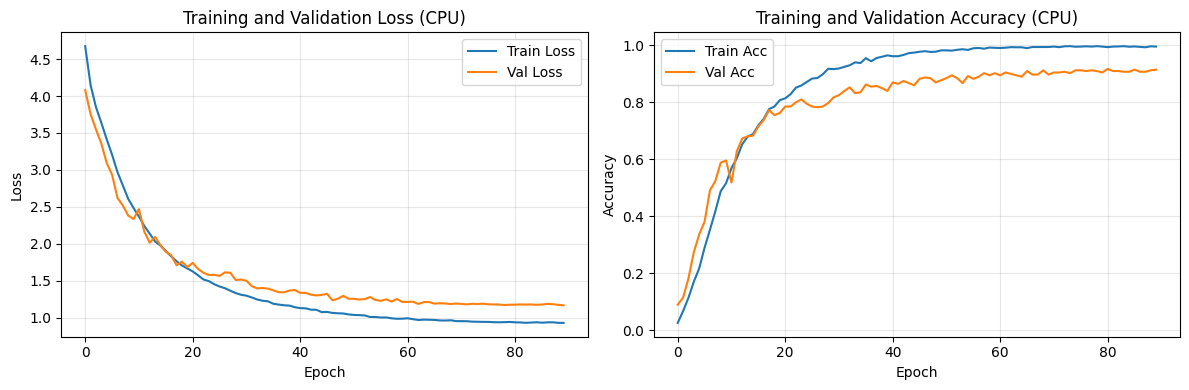

📊 Training curves saved to 'training_curves_cpu.png'

✅ TRAINING COMPLETE (CPU MODE)!


In [8]:
# ============================================================
# CPU-OPTIMIZED TCN FOR ASL LANDMARKS (TRAINING)
# Using Pre-split Data
# ============================================================

import numpy as np
from pathlib import Path
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

# ============================================================
# CONFIG (CPU OPTIMIZED)
# ============================================================

DEVICE = "cpu"  # Force CPU usage

TARGET_FRAMES = 120
FEATURE_DIM = 438

# CPU-optimized batch size (smaller for CPU)
BATCH_SIZE = 4  # Reduced from 8 for CPU
EPOCHS = 90
LR = 3e-4
WEIGHT_DECAY = 1e-4

PATIENCE = 12
GRAD_CLIP = 1.0
LABEL_SMOOTH = 0.1

# Use fewer workers for CPU
NUM_WORKERS = 0  # Set to 0 to avoid multiprocessing issues

MODEL_SAVE_PATH = "tcn_best_model_cpu.pth"
LABEL_ENCODER_PATH = "label_encoder.npy"

# ============================================================
# LOAD YOUR DATA
# ============================================================

train_data = splits['train']['data']
train_labels = splits['train']['labels']
val_data = splits['val']['data']
val_labels = splits['val']['labels']
test_data = splits['test']['data']
test_labels = splits['test']['labels']

print("="*60)
print("📊 DATA INFORMATION (CPU MODE)")
print("="*60)
print(f"Train data type: {type(train_data)}")
print(f"Train data shape: {train_data.shape if hasattr(train_data, 'shape') else len(train_data)}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Val data shape: {val_data.shape if hasattr(val_data, 'shape') else len(val_data)}")
print(f"Val labels shape: {val_labels.shape}")
print(f"Test data shape: {test_data.shape if hasattr(test_data, 'shape') else len(test_data)}")
print(f"Test labels shape: {test_labels.shape}")
print(f"Device: {DEVICE}")
print(f"Batch size: {BATCH_SIZE} (CPU optimized)")

# ============================================================
# CONVERT DATA TO CORRECT FORMAT
# ============================================================

def convert_to_array(data):
    """
    Convert object array to float32 numpy array
    """
    if isinstance(data, np.ndarray) and data.dtype == np.object_:
        # Stack all sequences into a single array
        shapes = [seq.shape for seq in data]
        if len(set(shapes)) > 1:
            print(f"⚠️ Warning: Different shapes found: {set(shapes)}")
            # Filter to keep only sequences with correct shape
            valid_indices = [i for i, seq in enumerate(data) if seq.shape == (TARGET_FRAMES, FEATURE_DIM)]
            print(f"Keeping {len(valid_indices)}/{len(data)} valid sequences")
            data = [data[i] for i in valid_indices]
        return np.stack(data).astype(np.float32)
    return data.astype(np.float32)

# Convert data
print("\n🔄 Converting data to correct format...")
train_data = convert_to_array(train_data)
val_data = convert_to_array(val_data)
test_data = convert_to_array(test_data)

print(f"Train data shape after conversion: {train_data.shape}")
print(f"Val data shape after conversion: {val_data.shape}")
print(f"Test data shape after conversion: {test_data.shape}")

# Also filter labels to match valid indices if needed
if len(train_data) != len(train_labels):
    print(f"⚠️ Adjusting labels to match data: {len(train_labels)} -> {len(train_data)}")
    train_labels = train_labels[:len(train_data)]
    val_labels = val_labels[:len(val_data)]
    test_labels = test_labels[:len(test_data)]

# ============================================================
# ENCODE LABELS
# ============================================================

all_labels = np.concatenate([train_labels, val_labels, test_labels])
le = LabelEncoder()
le.fit(all_labels)
num_classes = len(le.classes_)

y_train_encoded = le.transform(train_labels)
y_val_encoded = le.transform(val_labels)
y_test_encoded = le.transform(test_labels)

np.save(LABEL_ENCODER_PATH, le.classes_)
print(f"\n🏷️ Label encoding complete: {num_classes} unique glosses")

# ============================================================
# DATASET CLASS (NO MASK)
# ============================================================

class ASLDataset(Dataset):
    def __init__(self, data, labels):
        """
        data: numpy array of shape (n_samples, TARGET_FRAMES, FEATURE_DIM)
        labels: numpy array of encoded labels
        """
        self.data = torch.from_numpy(data).float()
        self.labels = torch.from_numpy(labels).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Transpose to (FEATURE_DIM, TARGET_FRAMES) for Conv1d
        x = self.data[idx].transpose(0, 1)  # (438, 120)
        y = self.labels[idx]
        return x, y

# Create dataloaders (CPU optimized)
train_dataset = ASLDataset(train_data, y_train_encoded)
val_dataset = ASLDataset(val_data, y_val_encoded)
test_dataset = ASLDataset(test_data, y_test_encoded)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"\n✅ DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# ============================================================
# MODEL DEFINITION (CPU OPTIMIZED - Smaller Model)
# ============================================================

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__()
        padding = dilation
        # Reduced channel sizes for CPU
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, 3, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),  # inplace=True saves memory
            nn.Conv1d(out_channels, out_channels, 3, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )
        self.res = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        y = self.net(x)
        y = y[..., :x.size(2)]
        return y + self.res(x)

class TCN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        # Reduced channel sizes for CPU (from 192 to 128)
        channels = [128, 128, 128, 128]  # Smaller than original 192
        
        layers = []
        for i, c in enumerate(channels):
            in_dim = input_dim if i == 0 else channels[i-1]
            layers.append(TemporalBlock(in_dim, c, dilation=2**i))
        
        self.tcn = nn.Sequential(*layers)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(channels[-1], num_classes)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        """
        x: (batch, features, time)
        """
        x = self.tcn(x)                    # (batch, channels, time)
        x = self.global_avg_pool(x)        # (batch, channels, 1)
        x = x.squeeze(-1)                  # (batch, channels)
        x = self.dropout(x)
        return self.fc(x)                  # (batch, num_classes)

model = TCN(input_dim=FEATURE_DIM, num_classes=num_classes).to(DEVICE)

print(f"\n📐 Model Architecture (CPU Optimized):")
print(f"  Input: {FEATURE_DIM} features x {TARGET_FRAMES} frames")
print(f"  Output: {num_classes} classes")
print(f"  Channel size: 128 (reduced from 192)")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# ============================================================
# LOSS FUNCTION WITH CLASS WEIGHTS
# ============================================================

# Compute class weights for imbalanced dataset
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

class SmoothCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight
        
    def forward(self, logits, targets):
        n_classes = logits.size(1)
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        
        log_probs = torch.log_softmax(logits, dim=1)
        
        if self.weight is not None:
            weight = self.weight[targets]
            loss = -(true_dist * log_probs).sum(dim=1) * weight
        else:
            loss = -(true_dist * log_probs).sum(dim=1)
            
        return loss.mean()

criterion = SmoothCrossEntropy(smoothing=LABEL_SMOOTH, weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        
        total_loss += loss.item() * y.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y).sum().item()
        total += y.size(0)
    
    return total_loss / total, correct / total

def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            outputs = model(x)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * y.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(y).sum().item()
            total += y.size(0)
    
    return total_loss / total, correct / total

# ============================================================
# TRAINING LOOP
# ============================================================

print("\n" + "="*60)
print("🚀 STARTING TRAINING (CPU MODE)")
print("="*60)
print("⚠️ Training on CPU will be slower. Consider using GPU if available.")
print("="*60)

best_val_acc = 0
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(train_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    val_loss, val_acc = evaluate(val_loader)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Update scheduler
    scheduler.step()
    
    # Print progress
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, MODEL_SAVE_PATH)
        print(f"  ✅ Best model saved! (Val Acc: {val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            break

# ============================================================
# FINAL EVALUATION
# ============================================================

print("\n" + "="*60)
print("📊 FINAL EVALUATION")
print("="*60)

# Load best model
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=torch.device('cpu'))
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with Val Acc: {checkpoint['val_acc']:.4f}")

# Test evaluation
test_loss, test_acc = evaluate(test_loader)
print(f"\n🎯 Test Set Results:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")

# Per-class accuracy
def per_class_accuracy(loader, model, num_classes):
    model.eval()
    class_correct = torch.zeros(num_classes)
    class_total = torch.zeros(num_classes)
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            outputs = model(x)
            _, predicted = outputs.max(1)
            
            for i in range(len(y)):
                label = y[i]
                class_correct[label] += (predicted[i] == label).item()
                class_total[label] += 1
    
    return class_correct / (class_total + 1e-6)

per_class_acc = per_class_accuracy(test_loader, model, num_classes)
print(f"\n📈 Per-class accuracy (first 10 classes):")
for i in range(min(10, num_classes)):
    print(f"  Class {le.classes_[i]}: {per_class_acc[i]:.4f}")

# Find worst performing classes
worst_classes = np.argsort(per_class_acc.numpy())[:5]
print(f"\n⚠️ Worst performing classes:")
for i in worst_classes:
    print(f"  Class {le.classes_[i]}: {per_class_acc[i]:.4f}")

# ============================================================
# SAVE TRAINING HISTORY
# ============================================================

import pickle

history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'num_classes': num_classes,
    'target_frames': TARGET_FRAMES,
    'feature_dim': FEATURE_DIM
}

with open('training_history_cpu.pkl', 'wb') as f:
    pickle.dump(history, f)

print(f"\n💾 Training history saved to 'training_history_cpu.pkl'")
print(f"💾 Best model saved to {MODEL_SAVE_PATH}")
print(f"💾 Label encoder saved to {LABEL_ENCODER_PATH}")

# ============================================================
# PLOT TRAINING CURVES
# ============================================================

try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss plot
    axes[0].plot(train_losses, label='Train Loss')
    axes[0].plot(val_losses, label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss (CPU)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(train_accs, label='Train Acc')
    axes[1].plot(val_accs, label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy (CPU)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves_cpu.png', dpi=150)
    plt.show()
    print("📊 Training curves saved to 'training_curves_cpu.png'")
    
except Exception as e:
    print(f"⚠️ Could not plot: {e}")

print("\n" + "="*60)
print("✅ TRAINING COMPLETE (CPU MODE)!")
print("="*60)